In [1]:
import math
import os
import sys
import time

# nanoVLM Imports
sys.path.append("..") 
from data.collators import VQACollator, MMStarCollator
from data.datasets import MMStarDataset, VQADataset
from data.processors import get_image_processor, get_tokenizer
from models.vision_language_model import VisionLanguageModel
import models.utils as utils
from models.config import TrainConfig, VLMConfig

# Libraries
from dataclasses import dataclass, field
from datasets import load_dataset, concatenate_datasets
import matplotlib.pyplot as plt
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm

# Otherwise, the tokenizer will through a warning
os.environ["TOKENIZERS_PARALLELISM"] = "false"

os.environ["HF_ENDPOINT"] = "https://hf-mirror.com"

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using device: {device}")

torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

# To reload the modules if you change something in the code
%reload_ext autoreload
%autoreload 2

Using device: mps


In [2]:
# Vision Transformer (ViT) config
vit_img_size = 224
vit_model_type = 'google/siglip-base-patch16-224'

# Language Model config
lm_max_length = 128
lm_model_type = 'HuggingFaceTB/SmolLM2-135M'
lm_tokenizer = 'HuggingFaceTB/cosmo2-tokenizer'

# Modality Projector config
mp_pixel_shuffle_factor = 2
mp_image_token_length = 49

hf_repo_name = 'nanoVLM'

vlm_cfg = VLMConfig(
    vit_img_size = vit_img_size,
    vit_model_type = vit_model_type,
    lm_max_length = lm_max_length,
    lm_model_type = lm_model_type,
    lm_tokenizer = lm_tokenizer,
    mp_pixel_shuffle_factor = mp_pixel_shuffle_factor,
    mp_image_token_length = mp_image_token_length,
    vlm_extra_tokens = {"image_token": "<|image|>"},
    vlm_load_backbone_weights = True,
    vlm_checkpoint_path = 'checkpoints',
    hf_repo_name = hf_repo_name,
)

In [3]:
# Learning rates
lr_mp = 1e-3
lr_backbones = 5e-5

# Use a small subset of the data at first, set it to None for using full set.
data_cutoff_idx = 1024
val_ratio = 0.2

batch_size = 12
gradient_accumulation_steps = 4
mmstar_batch_size = 32  # for mmstar-benchmark

max_grad_norm= 1.0
eval_in_epochs = False  # Deactivating in this notebook.
eval_interval = 250  # Evaluated on the validation and MMStar test datasets every 250 steps.
epochs = 5
resume_from_vlm_checkpoint = False  # Resume from checkpoint or train from scratch.

train_dataset_path = "HuggingFaceM4/the_cauldron"
train_dataset_name = ("tqa", "vsr")  # All options; ("ai2d", "aokvqa", "chart2text", "chartqa", "clevr", "cocoqa", "datikz", "diagram_image_to_text", "docvqa", "dvqa", "figureqa", "finqa", "geomverse", "hateful_memes", "hitab", "iam", "iconqa", "infographic_vqa", "intergps", "localized_narratives", "mapqa", "multihiertt", "ocrvqa", "plotqa", "raven", "rendered_text", "robut_sqa", "robut_wikisql", "robut_wtq", "scienceqa", "screen2words", "st_vqa", "tabmwp", "tallyqa", "tat_qa", "textcaps", "textvqa", "tqa", "vistext", "visual7w", "visualmrc", "vqarad", "vqav2", "vsr", "websight") # "clevr_math", "okvqa", "spot_the_diff", "nlvr2", "mimic_cgd",
test_dataset_path = "Lin-Chen/MMStar"

# wandb_entity: str = "HuggingFace" # Indicate the entity to log to in wandb
# log_wandb: bool = True

train_cfg = TrainConfig(
    lr_mp=lr_mp,
    lr_backbones=lr_backbones,
    data_cutoff_idx=data_cutoff_idx,
    val_ratio=val_ratio,
    batch_size=batch_size,
    gradient_accumulation_steps=gradient_accumulation_steps,
    mmstar_batch_size=mmstar_batch_size,
    max_grad_norm=max_grad_norm,
    eval_in_epochs=eval_in_epochs,
    eval_interval=eval_interval,
    epochs=epochs,
    resume_from_vlm_checkpoint=resume_from_vlm_checkpoint,
    train_dataset_path=train_dataset_path,
    train_dataset_name=train_dataset_name,
    test_dataset_path=test_dataset_path,
)

In [4]:
def get_dataloaders(train_cfg, vlm_cfg):
    # Create datasets
    image_processor = get_image_processor(vlm_cfg.vit_img_size)
    tokenizer = get_tokenizer(vlm_cfg.lm_tokenizer, vlm_cfg.vlm_extra_tokens)

    # Load and combine all training datasets
    combined_train_data = []
    for dataset_name in train_cfg.train_dataset_name:
        train_ds = load_dataset(train_cfg.train_dataset_path, dataset_name)
        combined_train_data.append(train_ds['train'])
    train_ds = concatenate_datasets(combined_train_data)
    
    test_ds = load_dataset(train_cfg.test_dataset_path)
    train_ds = train_ds.shuffle(seed=0) # Shuffle the training dataset, so train and val get equal contributions from all concatinated datasets

    # Apply cutoff if specified
    if train_cfg.data_cutoff_idx is None:
        total_samples = len(train_ds)  # Use the entire dataset
    else:
        total_samples = min(len(train_ds), train_cfg.data_cutoff_idx)

    val_size = int(total_samples * train_cfg.val_ratio)
    train_size = total_samples - val_size

    train_dataset = VQADataset(train_ds.select(range(train_size)), tokenizer, image_processor)
    val_dataset = VQADataset(train_ds.select(range(train_size, total_samples)), tokenizer, image_processor)
    test_dataset = MMStarDataset(test_ds['val'], tokenizer, image_processor)

    # Create collators
    vqa_collator = VQACollator(tokenizer, vlm_cfg.lm_max_length, vlm_cfg.mp_image_token_length)
    mmstar_collator = MMStarCollator(tokenizer, vlm_cfg.mp_image_token_length)

    # Create dataloaders
    train_loader = DataLoader(
        train_dataset,
        batch_size=train_cfg.batch_size,
        shuffle=True,
        collate_fn=vqa_collator,
        num_workers=2,
        pin_memory=True,
        drop_last=True,
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=train_cfg.batch_size,
        shuffle=False,
        collate_fn=vqa_collator,
        num_workers=2,
        pin_memory=True,
        drop_last=True,
    )

    test_loader = DataLoader(
        test_dataset, 
        batch_size=train_cfg.mmstar_batch_size, 
        shuffle=False, 
        collate_fn=mmstar_collator,
        pin_memory=True,
        )

    return train_loader, val_loader, test_loader

In [5]:
def test_mmstar(model, tokenizer, test_loader, device):
    # Go through MMStar and count how many answers we get right
    model.eval()
    total_examples = 0
    correct_predictions = 0
    with torch.no_grad():
        for batch in test_loader:
            image = batch['images'].to(device)
            input_ids = batch['input_ids'].to(device)
            labels = batch['labels'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            correct_answer = tokenizer.batch_decode(labels, skip_special_tokens=True)

            gen = model.generate(input_ids, image, attention_mask, greedy=True)
            model_output = tokenizer.batch_decode(gen, skip_special_tokens=True)

            is_correct = utils.check_multiple_choice_with_regex(model_output, correct_answer)

            total_examples += len(is_correct)
            if is_correct:
                correct_predictions += sum(is_correct)

    accuracy = correct_predictions / total_examples if total_examples > 0 else 0
    model.train()
    return accuracy

In [6]:
def get_lr(it, max_lr, max_steps):
    min_lr = max_lr * 0.1
    warmup_steps = max_steps * 0.03
    # 1) linear warmup for warmup_iters steps
    if it < warmup_steps:
        return max_lr * (it+1) / warmup_steps
    # 2) if it > lr_decay_iters, return min learning rate
    if it > max_steps:
        return min_lr
    # 3) in between, use cosine decay down to min learning rate
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps)
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # coeff starts at 1 and goes to 0
    return min_lr + coeff * (max_lr - min_lr)

def train(train_cfg, vlm_cfg, device):
    train_loader, val_loader, test_loader = get_dataloaders(train_cfg, vlm_cfg)
    tokenizer = get_tokenizer(vlm_cfg.lm_tokenizer, vlm_cfg.vlm_extra_tokens)

    # Initialize model
    if train_cfg.resume_from_vlm_checkpoint:
        model = VisionLanguageModel.from_pretrained(vlm_cfg.vlm_checkpoint_path)
    else:
        model = VisionLanguageModel(vlm_cfg)

    print(f"nanoVLM initialized with {sum(p.numel() for p in model.parameters()):,} parameters")
    print(f"Training summary: {len(train_loader.dataset)} samples, {len(train_loader)} batches/epoch, batch size {train_cfg.batch_size}")

    # Define optimizer groups
    param_groups = [{'params': model.MP.parameters(), 'lr': train_cfg.lr_mp},
                    {'params': list(model.decoder.parameters()) + list(model.vision_encoder.parameters()), 'lr': train_cfg.lr_backbones}]
    optimizer = optim.AdamW(param_groups)

    model.to(device)
    if train_cfg.compile:
        model = torch.compile(model)

    epoch_times = []
    batch_losses = []
    val_losses = []
    val_plot_steps = []
    best_accuracy = 0
    global_step = 0
    for epoch in range(train_cfg.epochs):
        epoch_start_time = time.time()
        model.train()
        total_train_loss = 0
        total_tokens_processed = 0

        for batch in tqdm(train_loader):
            batch_start_time = time.time()
            images = batch["image"].to(device)
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            optimizer.zero_grad()

            with torch.autocast(device_type=device, dtype=torch.float16): # Mixed precision training
                _, loss = model(input_ids, images, attention_mask=attention_mask, targets=labels)

            loss.backward()

            adj_lr_mp = get_lr(global_step, train_cfg.lr_mp, len(train_loader) * train_cfg.epochs)
            adj_lr_backbones = get_lr(global_step, train_cfg.lr_backbones, len(train_loader) * train_cfg.epochs)
            optimizer.param_groups[0]['lr'] = adj_lr_mp
            optimizer.param_groups[1]['lr'] = adj_lr_backbones

            optimizer.step()

            batch_loss = loss.item()
            total_train_loss += batch_loss
            batch_losses.append(batch_loss)

            num_tokens = torch.sum(attention_mask).item() # Sum of attention mask gives number of tokens
            num_tokens += images.shape[0] * ((images.shape[2] / vlm_cfg.vit_patch_size) ** 2) / (vlm_cfg.mp_pixel_shuffle_factor ** 2) # Add image tokens = batch_size * (((img_size / patch_size) ** 2) / (pixel_shuffle_factor ** 2))
            total_tokens_processed += num_tokens

            batch_end_time = time.time()
            batch_duration = batch_end_time - batch_start_time
            tokens_per_second = num_tokens / batch_duration

            if global_step % 5 == 0:
                model.eval()
                torch.cuda.empty_cache()  # Clear GPU memory
                with torch.no_grad():
                    total_val_loss = 0
                    for batch in val_loader:
                        images = batch["image"].to(device)
                        input_ids = batch["input_ids"].to(device)
                        labels = batch["labels"].to(device)
                        attention_mask = batch["attention_mask"].to(device)

                        with torch.amp.autocast(device_type=device, dtype=torch.float16):
                            _, loss = model(input_ids, images, attention_mask=attention_mask, targets=labels)

                        total_val_loss += loss.item()
                    avg_val_loss = total_val_loss / len(val_loader)
                    val_losses.append(avg_val_loss)
                    val_plot_steps.append(global_step)
                epoch_accuracy = 0
                if train_cfg.eval_in_epochs:
                    epoch_accuracy = test_mmstar(model, tokenizer, test_loader, device)
                    if epoch_accuracy > best_accuracy:
                      best_accuracy = epoch_accuracy
                      model.save_pretrained(save_directory=vlm_cfg.vlm_checkpoint_path)
                    print(f"\nStep: {global_step}, Loss: {batch_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Tokens/s: {tokens_per_second:.2f}, Accuracy: {epoch_accuracy:.4f}")
                model.train()

            global_step += 1

        avg_train_loss = total_train_loss / len(train_loader)

        epoch_end_time = time.time()
        epoch_duration = epoch_end_time - epoch_start_time
        epoch_times.append(epoch_duration)

        epoch_tokens_per_second = total_tokens_processed / epoch_duration

        print(f"Epoch {epoch+1}/{train_cfg.epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Time: {epoch_duration:.2f}s | T/s: {epoch_tokens_per_second:.2f}")

    # Summary Statistics
    if not train_cfg.eval_in_epochs:
      model.save_pretrained(save_directory=vlm_cfg.vlm_checkpoint_path)
      # model.push_to_hub(hf_model_name)


    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    total_training_time = sum(epoch_times)
    total_samples_processed = len(train_loader.dataset) * train_cfg.epochs
    avg_time_per_sample = total_training_time / total_samples_processed
    print(f"Average time per epoch: {avg_epoch_time:.2f}s")
    print(f"Average time per sample: {avg_time_per_sample:.4f}s")

    plt.plot(batch_losses, label='Train Loss')
    plt.plot(val_plot_steps, val_losses, label='Val Loss')
    plt.xlabel('Batch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.grid(True)
    plt.legend()
    plt.show()
    
    # With this code you can test the accuracy of the model on the MMStar dataset
    # But if you only train with few samples, the accuracy will be very low
    print("Testing MMStar Accuracy:")
    accuracy = test_mmstar(model, tokenizer, test_loader, device)
    print(f"MMStar Accuracy: {accuracy:.4f}")

Loading from backbone weights
Successfully loaded google/siglip-base-patch16-224 weights from safetensors. Model has 85,797,120 parameters.
Extending token embeddings from torch.Size([49152, 576]) to torch.Size([49153, 576])
Initialized 1 new token embeddings
Successfully loaded HuggingFaceTB/SmolLM2-135M weights from safetensors. Model has 134,515,584 parameters.
nanoVLM initialized with 222,082,176 parameters
Training summary: 820 samples, 68 batches/epoch, batch size 12


  0%|                                                                                                                                                                                          | 0/68 [00:00<?, ?it/s]/Users/yilin/miniconda3/envs/vlm_study/lib/python3.10/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [06:49<00:00,  6.03s/it]


Epoch 1/5 | Train Loss: 0.6675 | Val Loss: 0.2810 | Time: 409.72s | T/s: 275.15


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [06:51<00:00,  6.04s/it]


Epoch 2/5 | Train Loss: 0.3003 | Val Loss: 0.2789 | Time: 411.04s | T/s: 274.27


...

Epoch 3/5 | Train Loss: 0.2937 | Val Loss: 0.2754 | Time: 384.41s | T/s: 293.32


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [07:24<00:00,  6.53s/it]


Epoch 4/5 | Train Loss: 0.2864 | Val Loss: 0.2795 | Time: 444.19s | T/s: 253.85


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 68/68 [06:31<00:00,  5.76s/it]


Epoch 5/5 | Train Loss: 0.2811 | Val Loss: 0.2772 | Time: 391.50s | T/s: 287.92
Average time per epoch: 408.17s
Average time per sample: 0.4978s


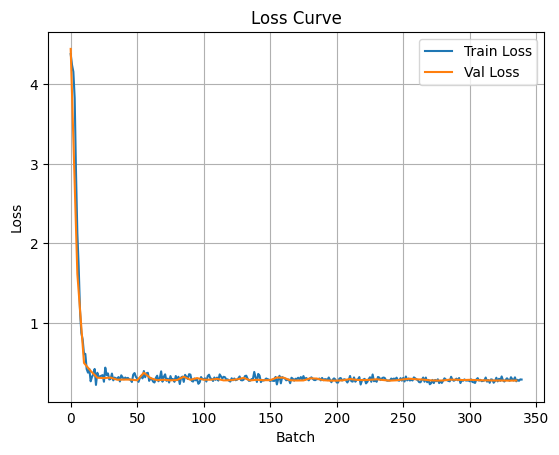

Testing MMStar Accuracy:
MMStar Accuracy: 0.2667


In [7]:
train(train_cfg, vlm_cfg, device)

In [8]:
model = VisionLanguageModel.from_pretrained(vlm_cfg.vlm_checkpoint_path)

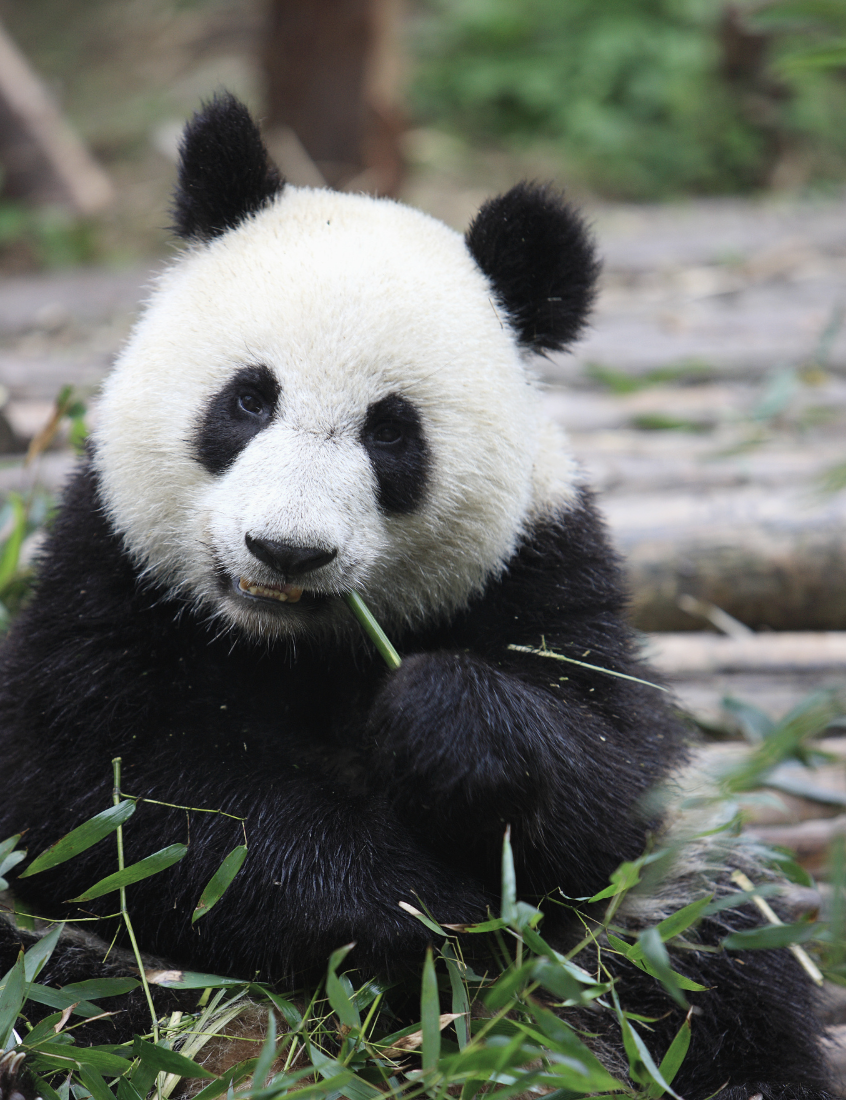


Input:
  What is this?
Choices:
A. Panda.
B. Cat.
C. Bear.
D. Lion.
 

Outputs:


In [ ]:
model.to(device)
model.eval()

tokenizer = get_tokenizer(model.cfg.lm_tokenizer, model.cfg.vlm_extra_tokens)
image_processor = get_image_processor(model.cfg.vit_img_size)

prompt = "What is this?\nChoices:\nA. Panda.\nB. Cat.\nC. Bear.\nD. Lion.\n"
template = f"{tokenizer.image_token * model.cfg.mp_image_token_length}Question: {prompt} Answer:"
encoded = tokenizer.batch_encode_plus([template], return_tensors="pt")
tokens = encoded["input_ids"].to(device)

from PIL import Image
from IPython.display import display
img = Image.open('test_image.png').convert("RGB")
img_t = image_processor(img).unsqueeze(0).to(device)

display(img)

num_generations = 3
max_new_tokens = 128
print("\nInput:\n ", prompt, "\n\nOutputs:")
for i in range(num_generations):
    gen = model.generate(tokens, img_t, max_new_tokens=max_new_tokens)
    out = tokenizer.batch_decode(gen, skip_special_tokens=True)[0]
    print(f"  >> Generation {i+1}: {out}")